# Refactored train/test split pipeline
This notebook orchestrates the original `train_test_split.ipynb` workflow using code extracted into the `src` package.


In [1]:
import os
import sys
import numpy as np

# Ensure TeX Live binaries are on PATH for matplotlib's usetex mode
os.environ['PATH'] = '/usr/local/texlive/2024/bin/universal-darwin:' + os.environ.get('PATH', '')

# Allow imports from the project root
sys.path.insert(0, os.path.abspath('..'))

from src.data_prep import prepare_data
from src import regression
from src.pipeline import FEATURE_SETS, plot_feature_histograms, reset_output_dir, run_baseline_regressions
from src.model_comparison import run_model_comparison
from src.classification import run_classification_analysis

import matplotlib
matplotlib.use("Agg")

In [2]:
if os.path.exists('outputs/paper_plots') is False:
    os.makedirs('outputs/paper_plots')

In [3]:
# Configuration flags and parameters
RUN_BASELINE_MODELS = True
RUN_BASELINE_MIXED = False
RUN_BASELINE_DOMAIN_SHIFT = True
BASELINE_MIXED_LABEL = 'Mixed split'
BASELINE_DOMAIN_LABEL = 'E-INSPIRE-to-INSPIRE'
BASELINE_PLOTTING = False
RANDOM_STATES = [1, 2, 3, 4, 5, 6, 7, 8, 9, 1000000]

RUN_HISTOGRAMS = False
RUN_CORNER = False
RUN_CORNER_BY_DATASET = True
RUN_RESIDUALS = False
RUN_CLASSIFICATION = True
RUN_MODEL_COMPARISON = True

MODEL_COMPARISON_SEEDS = [1,2,3,4,5]
MODEL_COMPARISON_MODES = [
    ('mixed', BASELINE_MIXED_LABEL),
    # ('domain_shift', 'E-INSPIRE→INSPIRE'),
]
CLASSIFICATION_THRESHOLDS = np.arange(0.25, 0.66, 0.05)
CLASSIFICATION_FEATURES = ['tau', 'lin_age_err', 'met', 'met_err', 'logM', 'rad_kpc']
CLASSIFICATION_DATASET_MODES = [
    ('mixed', BASELINE_MIXED_LABEL),
    # ('domain_shift', 'E-INSPIRE-INSPIRE'),
]

CORNER_FEATURES = ['met', 'tau', 'met_err', 'lin_age_err', 'logM', 'rad_kpc', 'MgFe', 'vdisp', 'DoR']
CORNER_TARGET_DISPLAY_NAME = r'$\mathrm{DoR}$'

RESIDUAL_FEATURES = ['tau', 'met']
RESIDUAL_MODEL_PARAMS = {
    'max_depth': 8,
    'max_features': 0.8,
    'max_samples': 0.7,
    'min_samples_leaf': 3,
    'min_samples_split': 5,
    'n_estimators': 50,
    'random_state': 42,
}


In [4]:
columns = ['vdisp','tau','MgFe', 'met_err', 'lin_age_err','met','rad_kpc','logM','DoR']
mixed_train_df, mixed_test_df = prepare_data(columns, restricted=False, pc=False, mix_datasets=True)
domain_train_df, domain_test_df = prepare_data(columns, restricted=False, pc=False, mix_datasets=False)

# Default references for downstream plots (mixed split)
train_df, test_df = mixed_train_df, mixed_test_df
regression.train_df = train_df
regression.test_df = test_df

# Unmixed data for E-INSPIRE vs INSPIRE visualisations
hist_train_df, hist_test_df = domain_train_df, domain_test_df


['ID', 'RAJ2000', 'DECJ2000', 'zspec_XSH', 'ageUni_at_z', 'Reff_median_KIDS_arcsec', 'Reff_median_KIDS_kpc', 'logM', 'Mstar(10^11)', 'vdisp', 'err_Vdisp_XSH', 'MgFe', 'err_alphafe', 'age_unr', 'age_rmax', 'lin_age_err', 'metal_unr', 'metal_rmax', 'met_err', 'tuni', 'Mtbb3', 'stdev_Mt3', 't_75', 'stdev_t75', 't_final', 'stdev_tifn', 'err_tfin', 'DoR', 'lin_age', 'met', 'SNR', 'rad_kpc', 'tau']
['ID', 'age_noboot', 'metals_noboot', 'age_boot', 'metals_boot', 'age_minus', 'metals_minus', 'ages_plus', 'metal_plus', 'GALAXY ID', 'univ_age', 'MgFe', 'vdisp', 'dor_26', 'logM', 'rad_kpc', 'age_err_mass', 'SNR', '[M/H]_mean_mass', '[M/H]_mean_1', 'DoR', '[M/H]', 'logAge_err', 'logAge', 'lin_age', 'lin_age_err', 'met_err', 'met', 'tau']
        vdisp       tau  MgFe   met_err  lin_age_err       met   rad_kpc  \
0  235.738250  0.080965   0.3  0.017160     0.190062  0.287000  0.502996   
1  211.042349  0.162209   0.2  0.021531     0.448946  0.242117  0.446138   
2  280.829136  0.082736   0.3  0.01

In [5]:
if RUN_HISTOGRAMS:
    if RUN_BASELINE_DOMAIN_SHIFT:
        # Unmixed E-INSPIRE vs INSPIRE
        plot_feature_histograms(hist_train_df, hist_test_df, tag='unmixed')
    if RUN_BASELINE_MIXED:
        # Mixed train/test split
        plot_feature_histograms(mixed_train_df, mixed_test_df, tag='mixed')


In [6]:
print(min(domain_test_df['tau']))

-0.02527460444488964


In [7]:
grid = False
if grid:
    # Grid test thing here
    import itertools
    import numpy as np
    from sklearn.model_selection import KFold
    from sklearn.preprocessing import StandardScaler
    from sklearn.svm import SVR
    from sklearn.metrics import r2_score

    # Use the mixed train data prepared above
    feature_list = ['met', 'tau', 'met_err', 'lin_age_err', 'logM', 'rad_kpc', 'MgFe', 'vdisp']
    X = train_df[feature_list].to_numpy()
    y = train_df['DoR'].to_numpy()

    # Expanded grid across kernels and their relevant params
    C_values = [0.1, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 3.0, 5.0]
    epsilon_values = [0.001, 0.005, 0.01, 0.02, 0.03, 0.05, 0.08, 0.1, 0.15]
    gamma_values = ['scale', 'auto', 0.01, 0.05, 0.1, 0.2]
    degree_values = [2, 3, 4]
    coef0_values = [0.0, 0.1, 0.5]
    kernels = ['rbf', 'linear', 'poly', 'sigmoid']

    cv = KFold(n_splits=5, shuffle=True, random_state=42)

    def eval_config(config):
        # Build model with config fields
        model = SVR(**config)
        fold_scores = []
        for train_idx, val_idx in cv.split(X):
            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X[train_idx])
            X_val_scaled = scaler.transform(X[val_idx])
            model.fit(X_train_scaled, y[train_idx])
            preds = model.predict(X_val_scaled)
            fold_scores.append(r2_score(y[val_idx], preds))
        return float(np.mean(fold_scores))

    configs = []
    for kernel in kernels:
        for C in C_values:
            for eps in epsilon_values:
                if kernel == 'rbf':
                    for gamma in gamma_values:
                        configs.append({'kernel': kernel, 'C': C, 'epsilon': eps, 'gamma': gamma})
                elif kernel == 'linear':
                    configs.append({'kernel': kernel, 'C': C, 'epsilon': eps})
                elif kernel == 'poly':
                    for degree in degree_values:
                        for gamma in gamma_values:
                            for coef0 in coef0_values:
                                configs.append({
                                    'kernel': kernel, 'C': C, 'epsilon': eps,
                                    'degree': degree, 'gamma': gamma, 'coef0': coef0
                                })
                elif kernel == 'sigmoid':
                    for gamma in gamma_values:
                        for coef0 in coef0_values:
                            configs.append({'kernel': kernel, 'C': C, 'epsilon': eps, 'gamma': gamma, 'coef0': coef0})

    results = []
    for idx, cfg in enumerate(configs, 1):
        score = eval_config(cfg)
        results.append((cfg, score))
        if idx % 100 == 0:
            print(f'Evaluated {idx}/{len(configs)} configs...')

    results = sorted(results, key=lambda x: x[1], reverse=True)
    print('Top grid combos (kernel, C, epsilon, gamma, degree, coef0 -> mean R^2):')
    for cfg, score in results[:15]:
        print(cfg, '->', f'{score:.4f}')


In [8]:
# Prepare output directory used throughout the pipeline
reset_output_dir('outputs/tests')


In [9]:
if RUN_BASELINE_MODELS:
    if RUN_BASELINE_MIXED:
        run_baseline_regressions(mixed_train_df, mixed_test_df, RANDOM_STATES, plotting=BASELINE_PLOTTING, tag=BASELINE_MIXED_LABEL)
        ensemble_mixed = regression.calculate_ensemble_metrics(
            dataset_frames={
            BASELINE_MIXED_LABEL: (mixed_train_df, mixed_test_df),
            BASELINE_DOMAIN_LABEL: (domain_train_df, domain_test_df),
            },
            filter_tags=[BASELINE_MIXED_LABEL],
            output_path='outputs/paper_plots/ensemble_results_mixed.csv',
        )
    if RUN_BASELINE_DOMAIN_SHIFT:
        run_baseline_regressions(domain_train_df, domain_test_df, RANDOM_STATES, plotting=BASELINE_PLOTTING, tag=BASELINE_DOMAIN_LABEL)
        regression.print_results_summary()
        ensemble_domain = regression.calculate_ensemble_metrics(
            dataset_frames={
                BASELINE_MIXED_LABEL: (mixed_train_df, mixed_test_df),
                BASELINE_DOMAIN_LABEL: (domain_train_df, domain_test_df),
            },
            filter_tags=[BASELINE_DOMAIN_LABEL],
            output_path='outputs/paper_plots/ensemble_results_domain_shift.csv',
        )


/Users/charl/Programming/AS01_E_INSPIRE/src/regression.py:187: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_summary = pd.concat([results_summary, pd.DataFrame({


Model Name                          | Test R²: Mean ± Std       | Test R²: Min-Max          | Train R²: Mean ± Std      | Train R²: Min-Max        
------------------------------------------------------------------------------------------------------------------------
Complete Set [E-INSPIRE-to-INSPIRE] | 0.7991 ± 0.0000 | 0.7991 - 0.7991 | 0.8273 ± 0.0035 | 0.8220 - 0.8328
Stel. pop. [E-INSPIRE-to-INSPIRE]   | 0.7940 ± 0.0000 | 0.7940 - 0.7940 | 0.7771 ± 0.0056 | 0.7687 - 0.7832
Stel. pop. and $\alpha$-abundance [E-INSPIRE-to-INSPIRE] | 0.8078 ± 0.0000 | 0.8078 - 0.8078 | 0.8226 ± 0.0043 | 0.8160 - 0.8296
Stel. pop. and kinematics [E-INSPIRE-to-INSPIRE] | 0.8163 ± 0.0000 | 0.8163 - 0.8163 | 0.8260 ± 0.0027 | 0.8223 - 0.8306
Stel. pop. and structural [E-INSPIRE-to-INSPIRE] | 0.7833 ± 0.0000 | 0.7833 - 0.7833 | 0.8185 ± 0.0031 | 0.8146 - 0.8262
Stel. pop. with errors [E-INSPIRE-to-INSPIRE] | 0.7960 ± 0.0000 | 0.7960 - 0.7960 | 0.8197 ± 0.0046 | 0.8117 - 0.8258
Stel. pop., $\alpha$-abund

/Users/charl/Programming/AS01_E_INSPIRE/src/regression.py:1018: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  ensemble_results = pd.concat([ensemble_results, pd.DataFrame({



R² Variation Metrics Across Random Seeds:
                                                                name  test_r2_avg test_r2_std  train_r2_avg  train_r2_std
                                 Complete Set [E-INSPIRE-to-INSPIRE]        0.799           0         0.827         0.003
                                   Stel. pop. [E-INSPIRE-to-INSPIRE]        0.794           0         0.777         0.005
            Stel. pop. and $\alpha$-abundance [E-INSPIRE-to-INSPIRE]        0.808           0         0.823         0.004
                    Stel. pop. and kinematics [E-INSPIRE-to-INSPIRE]        0.816           0         0.826         0.003
                    Stel. pop. and structural [E-INSPIRE-to-INSPIRE]        0.783           0         0.818         0.003
                       Stel. pop. with errors [E-INSPIRE-to-INSPIRE]        0.796           0         0.820         0.004
Stel. pop., $\alpha$-abundance and kinematics [E-INSPIRE-to-INSPIRE]        0.824           0         0

In [10]:
if RUN_CORNER:
    regression.create_corner_plots(
        hist_test_df,
        CORNER_FEATURES,
        target='DoR',
        target_display_name=CORNER_TARGET_DISPLAY_NAME,
    )
    regression.create_corner_plots(
        hist_train_df,
        CORNER_FEATURES,
        target='DoR',
        target_display_name=CORNER_TARGET_DISPLAY_NAME,
    )


In [11]:
if RUN_CORNER_BY_DATASET:
    feature_display_names = {
        'met': r'$\mathrm{[M/H] \, (dex)}$',
        'tau': r'$\tau_{\rm rel}$',
        'met_err': r'$\Delta\mathrm{[M/H] \, (dex)}$',
        'lin_age_err': r'$\Delta\mathrm{Age \, (Gyr)}$',
        'logM': r'$\log(M_{\star}/M_{\odot})$',
        'rad_kpc': r'$R_{\rm e} \, \mathrm{(kpc)}$',
        'MgFe': r'$\mathrm{[Mg/Fe] \, (dex)}$',
        'vdisp': r'$\sigma_{\star} \, \mathrm{(km/s)}$',
        'DoR': r'$\mathrm{DoR}$',
    }
    regression.plot_features_by_dataset(
        hist_train_df,
        hist_test_df,
        CORNER_FEATURES,
        feature_display_names=feature_display_names,
    )


In [12]:
if RUN_RESIDUALS:
    regression.create_residual_analysis_report(
        train_df,
        test_df,
        RESIDUAL_FEATURES,
        'DoR',
        RESIDUAL_MODEL_PARAMS,
    )


In [13]:
if RUN_CLASSIFICATION:
    for dataset_mode, dataset_label in CLASSIFICATION_DATASET_MODES:
        cv_results = run_classification_analysis(CLASSIFICATION_THRESHOLDS, CLASSIFICATION_FEATURES, dataset_mode=dataset_mode, dataset_label=dataset_label)


['ID', 'RAJ2000', 'DECJ2000', 'zspec_XSH', 'ageUni_at_z', 'Reff_median_KIDS_arcsec', 'Reff_median_KIDS_kpc', 'logM', 'Mstar(10^11)', 'vdisp', 'err_Vdisp_XSH', 'MgFe', 'err_alphafe', 'age_unr', 'age_rmax', 'lin_age_err', 'metal_unr', 'metal_rmax', 'met_err', 'tuni', 'Mtbb3', 'stdev_Mt3', 't_75', 'stdev_t75', 't_final', 'stdev_tifn', 'err_tfin', 'DoR', 'lin_age', 'met', 'SNR', 'rad_kpc', 'tau']
['ID', 'age_noboot', 'metals_noboot', 'age_boot', 'metals_boot', 'age_minus', 'metals_minus', 'ages_plus', 'metal_plus', 'GALAXY ID', 'univ_age', 'MgFe', 'vdisp', 'dor_26', 'logM', 'rad_kpc', 'age_err_mass', 'SNR', '[M/H]_mean_mass', '[M/H]_mean_1', 'DoR', '[M/H]', 'logAge_err', 'logAge', 'lin_age', 'lin_age_err', 'met_err', 'met', 'tau']
        vdisp       tau  MgFe   met_err  lin_age_err       met   rad_kpc  \
0  235.738250  0.080965   0.3  0.017160     0.190062  0.287000  0.502996   
1  211.042349  0.162209   0.2  0.021531     0.448946  0.242117  0.446138   
2  280.829136  0.082736   0.3  0.01

In [14]:
MODEL_COMPARISON_SEEDS = [3,4,5,6,7]
if RUN_MODEL_COMPARISON:
    for dataset_mode, dataset_label in MODEL_COMPARISON_MODES:
        results_df, agg_results = run_model_comparison(MODEL_COMPARISON_SEEDS, True, dataset_mode=dataset_mode, dataset_label=dataset_label)
    print('Model comparison completed and results saved to outputs/tests/')



Running model comparison with 5 random seeds: [3, 4, 5, 6, 7]...
['ID', 'RAJ2000', 'DECJ2000', 'zspec_XSH', 'ageUni_at_z', 'Reff_median_KIDS_arcsec', 'Reff_median_KIDS_kpc', 'logM', 'Mstar(10^11)', 'vdisp', 'err_Vdisp_XSH', 'MgFe', 'err_alphafe', 'age_unr', 'age_rmax', 'lin_age_err', 'metal_unr', 'metal_rmax', 'met_err', 'tuni', 'Mtbb3', 'stdev_Mt3', 't_75', 'stdev_t75', 't_final', 'stdev_tifn', 'err_tfin', 'DoR', 'lin_age', 'met', 'SNR', 'rad_kpc', 'tau']
['ID', 'age_noboot', 'metals_noboot', 'age_boot', 'metals_boot', 'age_minus', 'metals_minus', 'ages_plus', 'metal_plus', 'GALAXY ID', 'univ_age', 'MgFe', 'vdisp', 'dor_26', 'logM', 'rad_kpc', 'age_err_mass', 'SNR', '[M/H]_mean_mass', '[M/H]_mean_1', 'DoR', '[M/H]', 'logAge_err', 'logAge', 'lin_age', 'lin_age_err', 'met_err', 'met', 'tau']
        vdisp       tau  MgFe   met_err  lin_age_err       met   rad_kpc  \
0  235.738250  0.080965   0.3  0.017160     0.190062  0.287000  0.502996   
1  211.042349  0.162209   0.2  0.021531     0

<Figure size 4200x2400 with 1 Axes>

Created separate test and training performance plots
Model comparison completed and results saved to outputs/tests/


In [15]:
# Permutation Importance for SVR
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import precision_score, recall_score
from sklearn.model_selection import KFold

# Feature display names for plotting
feature_display_names = {
    'met': r'$\mathrm{[M/H]}$',
    'tau': r'$\mathrm{\tau_{\rm rel}}$',
    'met_err': r'$\Delta{\mathrm{[M/H]}}$',
    'lin_age_err': r'$\Delta{\mathrm{Age}}$',
    'logM': r'$\log(M/M_{\odot})$',
    'rad_kpc': r'$R \, \mathrm{(kpc)}$',
    'MgFe': r'$\mathrm{[Mg/Fe]}$',
    'vdisp': r'$\sigma_{\star} \, \mathrm{(km/s)}$',
}

# SVR parameters (best from grid search)
SVR_PARAMS = {
    'C': 5.0,
    'epsilon': 0.03,
    'kernel': 'poly',
    'gamma': 0.01,
    'degree': 3,
    'coef0': 0.5,
}

# Use domain shift data (E-INSPIRE -> INSPIRE)
# Complete set used for permutation importance
features = ['met', 'tau', 'met_err', 'lin_age_err', 'logM', 'rad_kpc', 'MgFe', 'vdisp']

X_train = domain_train_df[features]
y_train = domain_train_df['DoR']
X_test = domain_test_df[features]
y_test = domain_test_df['DoR']

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train SVR
model = SVR(**SVR_PARAMS)
model.fit(X_train_scaled, y_train)

# Calculate permutation importance on test set
print("Calculating permutation importance (this may take a moment)...")
result = permutation_importance(
    model, X_test_scaled, y_test,
    n_repeats=30,
    random_state=42,
    scoring='r2'
)

# Create results DataFrame
importance_df = pd.DataFrame({
    'feature': features,
    'importance_mean': result.importances_mean,
    'importance_std': result.importances_std,
    'display_name': [feature_display_names[f] for f in features]
}).sort_values('importance_mean', ascending=True)

print("\nPermutation Importance (Test Set):")
print("=" * 60)
for _, row in importance_df.iterrows():
    print(f"{row['feature']:15s}: {row['importance_mean']:.4f} ± {row['importance_std']:.4f}")

# Plot
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Computer Modern",
    "figure.dpi": 300,
    "font.size": 20,
})

fig, ax = plt.subplots(figsize=(10, 6))

y_pos = np.arange(len(importance_df))
ax.barh(y_pos, importance_df['importance_mean'], xerr=importance_df['importance_std'],
        align='center', alpha=0.8, color='steelblue', ecolor='black', capsize=3)
ax.set_yticks(y_pos)
ax.set_yticklabels(importance_df['display_name'], fontsize=20)
ax.set_xlabel(r'Permutation Importance', fontsize=22)
ax.set_title(r'SVR Permutation Importance (E-INSPIRE to INSPIRE)', fontsize=20)

# Add vertical line at 0
ax.axvline(x=0, color='red', linestyle='--', linewidth=1, alpha=0.7)

plt.tight_layout()
plt.savefig('outputs/paper_plots/svr_permutation_importance.pdf', bbox_inches='tight')
plt.show()

print(f"\nPlot saved to outputs/paper_plots/svr_permutation_importance.pdf")

# Extreme relic recognition - best and worst models at threshold 0.6
print("\nExtreme relic recognition at DoR >= 0.6 (test set):")
print("=" * 65)

relic_models = {
    'Best  (Stel. pop., alpha-abundance and kinematics)': ['met', 'tau', 'met_err', 'lin_age_err', 'MgFe', 'vdisp'],
    'Worst (Stel. pop. and structural / Euclid-like)':    ['met', 'tau', 'met_err', 'lin_age_err', 'logM', 'rad_kpc'],
}

y_true_binary = (y_test >= 0.6)
for label, feat_set in relic_models.items():
    sc = StandardScaler()
    Xtr = sc.fit_transform(domain_train_df[feat_set])
    Xte = sc.transform(domain_test_df[feat_set])
    m = SVR(**SVR_PARAMS)
    m.fit(Xtr, y_train)
    y_pred_binary = (m.predict(Xte) >= 0.6)
    precision = precision_score(y_true_binary, y_pred_binary, zero_division=0)
    recall    = recall_score(y_true_binary, y_pred_binary, zero_division=0)
    n_true = y_true_binary.sum()
    n_pred = y_pred_binary.sum()
    print(f"{label}")
    print(f"  precision={precision:.3f}, recall={recall:.3f}  "
          f"(true: {n_true}, predicted: {n_pred})")
    print()

Calculating permutation importance (this may take a moment)...

Permutation Importance (Test Set):
logM           : -0.0062 ± 0.0055
rad_kpc        : 0.0086 ± 0.0040
met_err        : 0.0104 ± 0.0049
vdisp          : 0.0167 ± 0.0053
met            : 0.0182 ± 0.0074
MgFe           : 0.0217 ± 0.0073
lin_age_err    : 0.0320 ± 0.0099
tau            : 1.4905 ± 0.2725

Plot saved to outputs/paper_plots/svr_permutation_importance.pdf

Extreme relic recognition at DoR >= 0.6 (test set):
Best  (Stel. pop., alpha-abundance and kinematics)
  precision=0.909, recall=0.833  (true: 12, predicted: 11)

Worst (Stel. pop. and structural / Euclid-like)
  precision=0.769, recall=0.833  (true: 12, predicted: 13)



/var/folders/3n/9x85t_2n6n3g72cpggj5301r0000gn/T/ipykernel_91076/953333126.py:96: UserWarning: Matplotlib is currently using agg, which is a non-GUI backend, so cannot show the figure.
  plt.show()


In [16]:
# SVC Feature Importance Trends Across DoR Thresholds (Euclid-like features)
# Train a NEW classifier at each threshold, measure permutation importance
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score

# Feature display names
feature_display_names = {
    'met': r'$\mathrm{[M/H]}$',
    'tau': r'$\tau_{\rm rel}$',
    'met_err': r'$\Delta\mathrm{[M/H]}$',
    'lin_age_err': r'$\Delta\mathrm{Age}$',
    'logM': r'$\log(M_{\star}/M_{\odot})$',
    'rad_kpc': r'$R_{\rm e}$',
}

# SVC parameters
SVC_PARAMS = {
    'C': 1.0,
    'kernel': 'rbf',
    'gamma': 'scale',
    'class_weight': 'balanced',
    'random_state': 42,
}

# Euclid-like features only
features = ['met', 'tau', 'met_err', 'lin_age_err', 'logM', 'rad_kpc']

# Use domain shift data
X_train = domain_train_df[features].values
y_train_continuous = domain_train_df['DoR'].values
X_test = domain_test_df[features].values
y_test_continuous = domain_test_df['DoR'].values

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Thresholds to analyze
thresholds = np.arange(0.30, 0.66, 0.05)

# Store results
importance_by_threshold = {}

print("Training SVC classifiers at each threshold (Euclid-like features)...")
print("=" * 70)

for threshold in thresholds:
    # Create binary labels
    y_train_binary = (y_train_continuous >= threshold).astype(int)
    y_test_binary = (y_test_continuous >= threshold).astype(int)
    
    # Check class balance
    pct_high = 100 * y_train_binary.mean()
    
    # Train classifier
    clf = SVC(**SVC_PARAMS)
    clf.fit(X_train_scaled, y_train_binary)
    
    # Evaluate
    y_pred = clf.predict(X_test_scaled)
    acc = accuracy_score(y_test_binary, y_pred)
    f1 = f1_score(y_test_binary, y_pred)
    
    # Calculate permutation importance on test set
    result = permutation_importance(
        clf, X_test_scaled, y_test_binary,
        n_repeats=30,
        random_state=42,
        scoring='accuracy'
    )
    
    importance_by_threshold[threshold] = {
        'means': result.importances_mean,
        'stds': result.importances_std
    }
    
    print(f"Threshold {threshold:.2f}: {pct_high:.1f}% high class | Acc: {acc:.3f} | F1: {f1:.3f}")

# Convert to DataFrame for plotting
plot_data = []
for threshold, data in importance_by_threshold.items():
    for i, feat in enumerate(features):
        plot_data.append({
            'threshold': threshold,
            'feature': feat,
            'importance': data['means'][i],
            'std': data['stds'][i],
            'display_name': feature_display_names[feat]
        })

importance_df = pd.DataFrame(plot_data)

# Plot feature importance trends
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Computer Modern",
    "figure.dpi": 300,
    "font.size": 20,
})

fig, ax = plt.subplots(figsize=(10, 6))

for feat in features:
    feat_data = importance_df[importance_df['feature'] == feat]
    display_name = feature_display_names[feat]
    line, = ax.plot(feat_data['threshold'], feat_data['importance'],
                    'o-', label=display_name, linewidth=2, markersize=6)
    ax.errorbar(feat_data['threshold'], feat_data['importance'],
                yerr=feat_data['std'],
                fmt='none', ecolor=line.get_color(),
                alpha=0.3, capsize=3, elinewidth=4, capthick=4)

ax.set_xlabel('DoR Classification Threshold', fontsize=20)
ax.set_ylabel('Permutation Importance', fontsize=20)
ax.set_ylim(top=0.33)
ax.legend(loc='upper right', fontsize=17)
ax.axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.5)
ax.set_xticks(thresholds)
ax.set_xticklabels([f'{t:.2f}' for t in thresholds])

plt.tight_layout()
plt.savefig('outputs/paper_plots/svc_feature_importance_trends_euclid.pdf', bbox_inches='tight')
plt.show()

# Print summary table
print("\n" + "=" * 90)
print("Feature Importance by Threshold (Euclid-like):")
print("=" * 90)
header = f"{'Feature':<12}"
for t in thresholds:
    header += f"{t:.2f}".center(12)
print(header)
print("-" * 90)

for feat in features:
    row = f"{feat:<12}"
    for t in thresholds:
        val = importance_df[(importance_df['feature'] == feat) & (importance_df['threshold'] == t)]['importance'].values[0]
        row += f"{val:>10.4f}  "
    print(row)



# Print std table
print("\n" + "=" * 90)
print("Feature Importance STD by Threshold (Euclid-like):")
print("=" * 90)
print(header)
print("-" * 90)

for feat in features:
    row = f"{feat:<12}"
    for t in thresholds:
        val = importance_df[(importance_df['feature'] == feat) & (importance_df['threshold'] == t)]['std'].values[0]
        row += f"{val:>10.4f}  "
    print(row)
print(f"\nPlot saved to outputs/paper_plots/svc_feature_importance_trends_euclid.pdf")

Training SVC classifiers at each threshold (Euclid-like features)...
Threshold 0.30: 83.9% high class | Acc: 0.904 | F1: 0.941
Threshold 0.35: 76.9% high class | Acc: 0.904 | F1: 0.932
Threshold 0.40: 70.9% high class | Acc: 0.808 | F1: 0.821
Threshold 0.45: 58.1% high class | Acc: 0.865 | F1: 0.837
Threshold 0.50: 39.6% high class | Acc: 0.904 | F1: 0.839
Threshold 0.55: 19.4% high class | Acc: 0.923 | F1: 0.857
Threshold 0.60: 9.7% high class | Acc: 0.923 | F1: 0.800
Threshold 0.65: 5.9% high class | Acc: 0.962 | F1: 0.889

Feature Importance by Threshold (Euclid-like):
Feature         0.30        0.35        0.40        0.45        0.50        0.55        0.60        0.65    
------------------------------------------------------------------------------------------
met             0.0019      0.0596      0.0186      0.0353      0.0346      0.0250      0.1109      0.0679  
tau             0.1654      0.2615      0.2179      0.2609      0.2128      0.1929      0.0865      0.1019  
met

/var/folders/3n/9x85t_2n6n3g72cpggj5301r0000gn/T/ipykernel_91076/2400074972.py:129: UserWarning: Matplotlib is currently using agg, which is a non-GUI backend, so cannot show the figure.
  plt.show()


In [17]:
def c_monthly(years, x0,
              nominal_return=0.11, inflation=0.04,
              contrib_start=20, contrib_end=60):
    # Annual real factor (NOT "nominal - inflation", but ratio of factors)
    annual_real_factor = (1 + nominal_return) / (1 + inflation)

    # Convert annual factor to monthly factor
    monthly_factor = annual_real_factor ** (1/12)

    months = years * 12
    x = float(x0)
    z = float(x0)

    for m in range(months):
        # Growth over the month
        x *= monthly_factor
        z *= monthly_factor

        # Linear ramp of ANNUAL contribution, then convert to monthly
        t = m / (months - 1) if months > 1 else 0.0
        annual_contrib = contrib_start + t * (contrib_end - contrib_start)
        x += annual_contrib / 12.0  # paid monthly

    return x, z

print(c_monthly(20, 150))


(2018.8566268664579, 551.9300611946101)


In [18]:
# Export E-INSPIRE II master catalogue (unrestricted / allZ fit)
# domain_train_df is the full E-INSPIRE training set before any train/test split,
# joining stel_pop_fit_allZ.csv + E-INSPIRE_I_master_catalogue + ppxf_stel_pop_test2_small
domain_train_df.to_csv('data/EINSPIRE_II_master_catalogue_allZ.csv', index=False)
print(f'Saved {len(domain_train_df)} galaxies to data/EINSPIRE_II_master_catalogue_allZ.csv')
print(f'Columns: {list(domain_train_df.columns)}')

Saved 454 galaxies to data/EINSPIRE_II_master_catalogue_allZ.csv
Columns: ['ID', 'age_noboot', 'metals_noboot', 'age_boot', 'metals_boot', 'age_minus', 'metals_minus', 'ages_plus', 'metal_plus', 'GALAXY ID', 'univ_age', 'MgFe', 'vdisp', 'dor_26', 'logM', 'rad_kpc', 'age_err_mass', 'SNR', '[M/H]_mean_mass', '[M/H]_mean_1', 'DoR', '[M/H]', 'logAge_err', 'logAge', 'lin_age', 'lin_age_err', 'met_err', 'met', 'tau', 'Source']


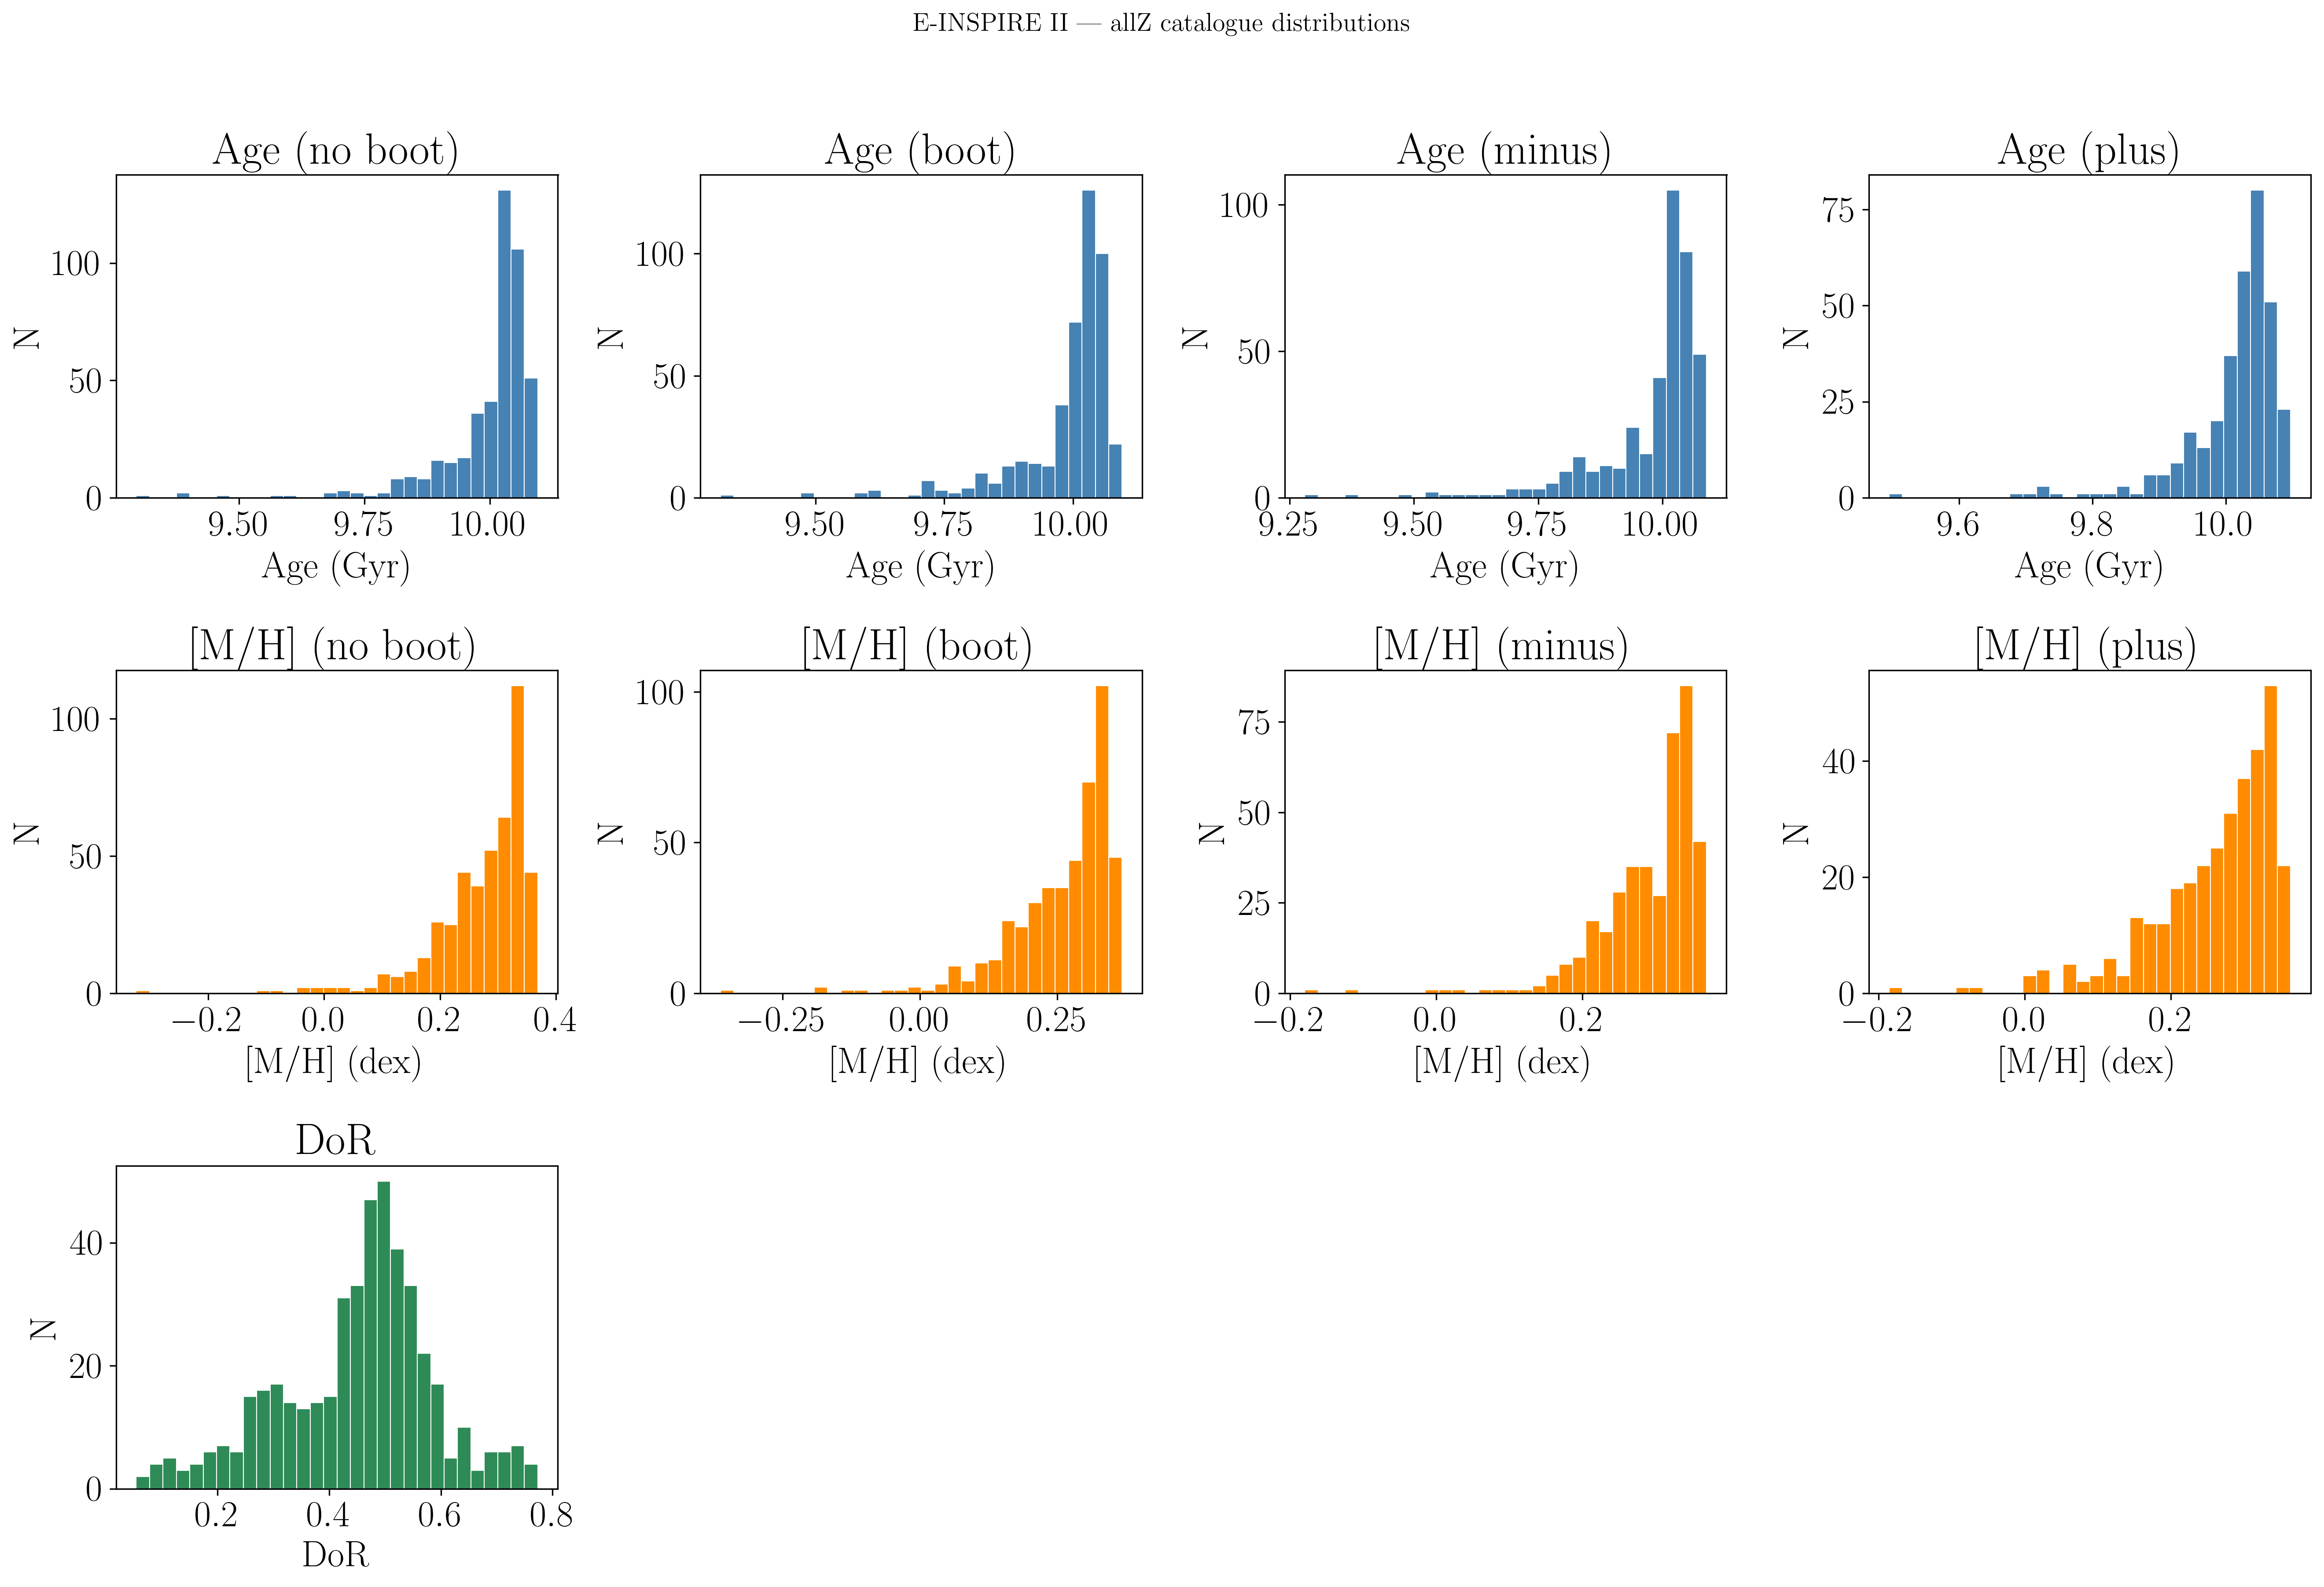

In [19]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(3, 4, figsize=(18, 12))

age_cols = ['age_noboot', 'age_boot', 'age_minus', 'ages_plus']
age_labels = ['Age (no boot)', 'Age (boot)', 'Age (minus)', 'Age (plus)']

met_cols = ['metals_noboot', 'metals_boot', 'metals_minus', 'metal_plus']
met_labels = ['[M/H] (no boot)', '[M/H] (boot)', '[M/H] (minus)', '[M/H] (plus)']

for i, (col, label) in enumerate(zip(age_cols, age_labels)):
    ax = axes[0, i]
    data = domain_train_df[col].dropna()
    ax.hist(data, bins=30, color='steelblue', edgecolor='white', linewidth=0.5)
    ax.set_title(label)
    ax.set_xlabel('Age (Gyr)')
    ax.set_ylabel('N')

for i, (col, label) in enumerate(zip(met_cols, met_labels)):
    ax = axes[1, i]
    data = domain_train_df[col].dropna()
    ax.hist(data, bins=30, color='darkorange', edgecolor='white', linewidth=0.5)
    ax.set_title(label)
    ax.set_xlabel('[M/H] (dex)')
    ax.set_ylabel('N')

ax = axes[2, 0]
data = domain_train_df['DoR'].dropna()
ax.hist(data, bins=30, color='seagreen', edgecolor='white', linewidth=0.5)
ax.set_title('DoR')
ax.set_xlabel('DoR')
ax.set_ylabel('N')

for j in range(1, 4):
    axes[2, j].set_visible(False)

plt.suptitle('E-INSPIRE II — allZ catalogue distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [20]:
print(domain_train_df['Source'].value_counts())

Source
1    454
Name: count, dtype: int64


In [21]:
# Kolmogorov-Smirnov test: E-INSPIRE (train) vs INSPIRE (test) feature distributions
from scipy.stats import ks_2samp
import pandas as pd

features = ['vdisp', 'tau', 'MgFe', 'met_err', 'lin_age_err', 'met', 'rad_kpc', 'logM', 'DoR']

feature_display_names = {
    'vdisp':       'vdisp (km/s)',
    'tau':         'tau_rel',
    'MgFe':        '[Mg/Fe]',
    'met_err':     'Delta [M/H]',
    'lin_age_err': 'Delta Age (Gyr)',
    'met':         '[M/H]',
    'rad_kpc':     'R_e (kpc)',
    'logM':        'log M*',
    'DoR':         'DoR',
}

rows = []
for feat in features:
    train_vals = domain_train_df[feat].dropna().values
    test_vals  = domain_test_df[feat].dropna().values
    stat, pval = ks_2samp(train_vals, test_vals)
    rows.append({
        'Feature':   feature_display_names[feat],
        'KS stat':   stat,
        'p-value':   pval,
        'Significant (p<0.05)': 'YES' if pval < 0.05 else 'no',
        'N train':   len(train_vals),
        'N test':    len(test_vals),
    })

ks_df = pd.DataFrame(rows).sort_values('KS stat', ascending=False)

print("KS test: E-INSPIRE (train) vs INSPIRE (test)")
print("=" * 65)
print(f"{'Feature':<20} {'KS stat':>8}  {'p-value':>10}  {'Sig?':>6}  N_train  N_test")
print("-" * 65)
for _, row in ks_df.iterrows():
    print(f"{row['Feature']:<20} {row['KS stat']:>8.4f}  {row['p-value']:>10.4e}  "
          f"{row['Significant (p<0.05)']:>6}  {row['N train']:>7}  {row['N test']:>6}")
print("=" * 65)


KS test: E-INSPIRE (train) vs INSPIRE (test)
Feature               KS stat     p-value    Sig?  N_train  N_test
-----------------------------------------------------------------
Delta [M/H]            0.5563  5.1734e-14     YES      454      52
vdisp (km/s)           0.4812  2.0428e-10     YES      454      52
[M/H]                  0.4252  3.8133e-08     YES      454      52
tau_rel                0.3055  2.3204e-04     YES      454      52
R_e (kpc)              0.2843  7.8431e-04     YES      454      52
log M*                 0.2819  8.9962e-04     YES      454      52
DoR                    0.2602  2.8221e-03     YES      454      52
Delta Age (Gyr)        0.2429  6.5382e-03     YES      454      52
[Mg/Fe]                0.0890  8.1832e-01      no      454      52


In [22]:
# Feature space overlap metrics: E-INSPIRE (train) vs INSPIRE (test)
# Quantifies "broadly overlapping" claim for reviewer response
import numpy as np
import pandas as pd

features = ['vdisp', 'tau', 'MgFe', 'met_err', 'lin_age_err', 'met', 'rad_kpc', 'logM', 'DoR']

feature_display_names = {
    'vdisp':       'vdisp (km/s)',
    'tau':         'tau_rel',
    'MgFe':        '[Mg/Fe]',
    'met_err':     'Delta [M/H]',
    'lin_age_err': 'Delta Age (Gyr)',
    'met':         '[M/H]',
    'rad_kpc':     'R_e (kpc)',
    'logM':        'log M*',
    'DoR':         'DoR',
}

rows = []
for feat in features:
    train_vals = domain_train_df[feat].dropna().values
    test_vals  = domain_test_df[feat].dropna().values

    # Overlap fraction: % of INSPIRE within E-INSPIRE 5th-95th percentile
    lo, hi = np.percentile(train_vals, [5, 95])
    overlap_pct = 100 * np.mean((test_vals >= lo) & (test_vals <= hi))

    # Normalised mean offset: (mu_test - mu_train) / sigma_train
    norm_offset = (np.mean(test_vals) - np.mean(train_vals)) / np.std(train_vals)

    # Range overlap: do [min, max] intervals intersect?
    range_overlap = (test_vals.min() < train_vals.max()) and (test_vals.max() > train_vals.min())

    rows.append({
        'Feature':          feature_display_names[feat],
        'Overlap (%)':      overlap_pct,
        'Norm. offset (σ)': norm_offset,
        'Range overlap':    'yes' if range_overlap else 'NO',
        'Train mean':       np.mean(train_vals),
        'Test mean':        np.mean(test_vals),
    })

metrics_df = pd.DataFrame(rows).sort_values('Overlap (%)', ascending=True)

print("Feature space overlap: E-INSPIRE (train) vs INSPIRE (test)")
print("=" * 75)
print(f"{'Feature':<20} {'Overlap (%)':>12}  {'Norm. offset (σ)':>17}  {'Range overlap':>14}")
print("-" * 75)
for _, row in metrics_df.iterrows():
    print(f"{row['Feature']:<20} {row['Overlap (%)']:>11.1f}%  "
          f"{row['Norm. offset (σ)']:>17.3f}  {row['Range overlap']:>14}")
print("=" * 75)
print(f"\nMedian overlap: {metrics_df['Overlap (%)'].median():.1f}%")
print(f"All feature ranges intersect: {(metrics_df['Range overlap'] == 'yes').all()}")


Feature space overlap: E-INSPIRE (train) vs INSPIRE (test)
Feature               Overlap (%)   Norm. offset (σ)   Range overlap
---------------------------------------------------------------------------
vdisp (km/s)                48.1%             -0.828             yes
tau_rel                     59.6%             -0.063             yes
[M/H]                       69.2%             -1.106             yes
DoR                         73.1%             -0.061             yes
Delta [M/H]                 98.1%              0.634             yes
R_e (kpc)                   98.1%              0.067             yes
[Mg/Fe]                    100.0%             -0.105             yes
Delta Age (Gyr)            100.0%             -0.378             yes
log M*                     100.0%             -0.192             yes

Median overlap: 98.1%
All feature ranges intersect: True


Computing R² across 8 feature sets × 2 splits × 2 algorithms ...
Done.

#    SVR-DS  SVR-Mix   RF-DS   RF-Mix
--------------------------------------
1     0.794    0.789   0.690    0.822
2     0.796    0.816   0.707    0.828
3     0.816    0.781   0.724    0.829
4     0.808    0.815   0.727    0.827
5     0.824    0.792   0.711    0.827
6     0.783    0.819   0.698    0.832
7     0.791    0.780   0.702    0.830
8     0.799    0.766   0.705    0.830


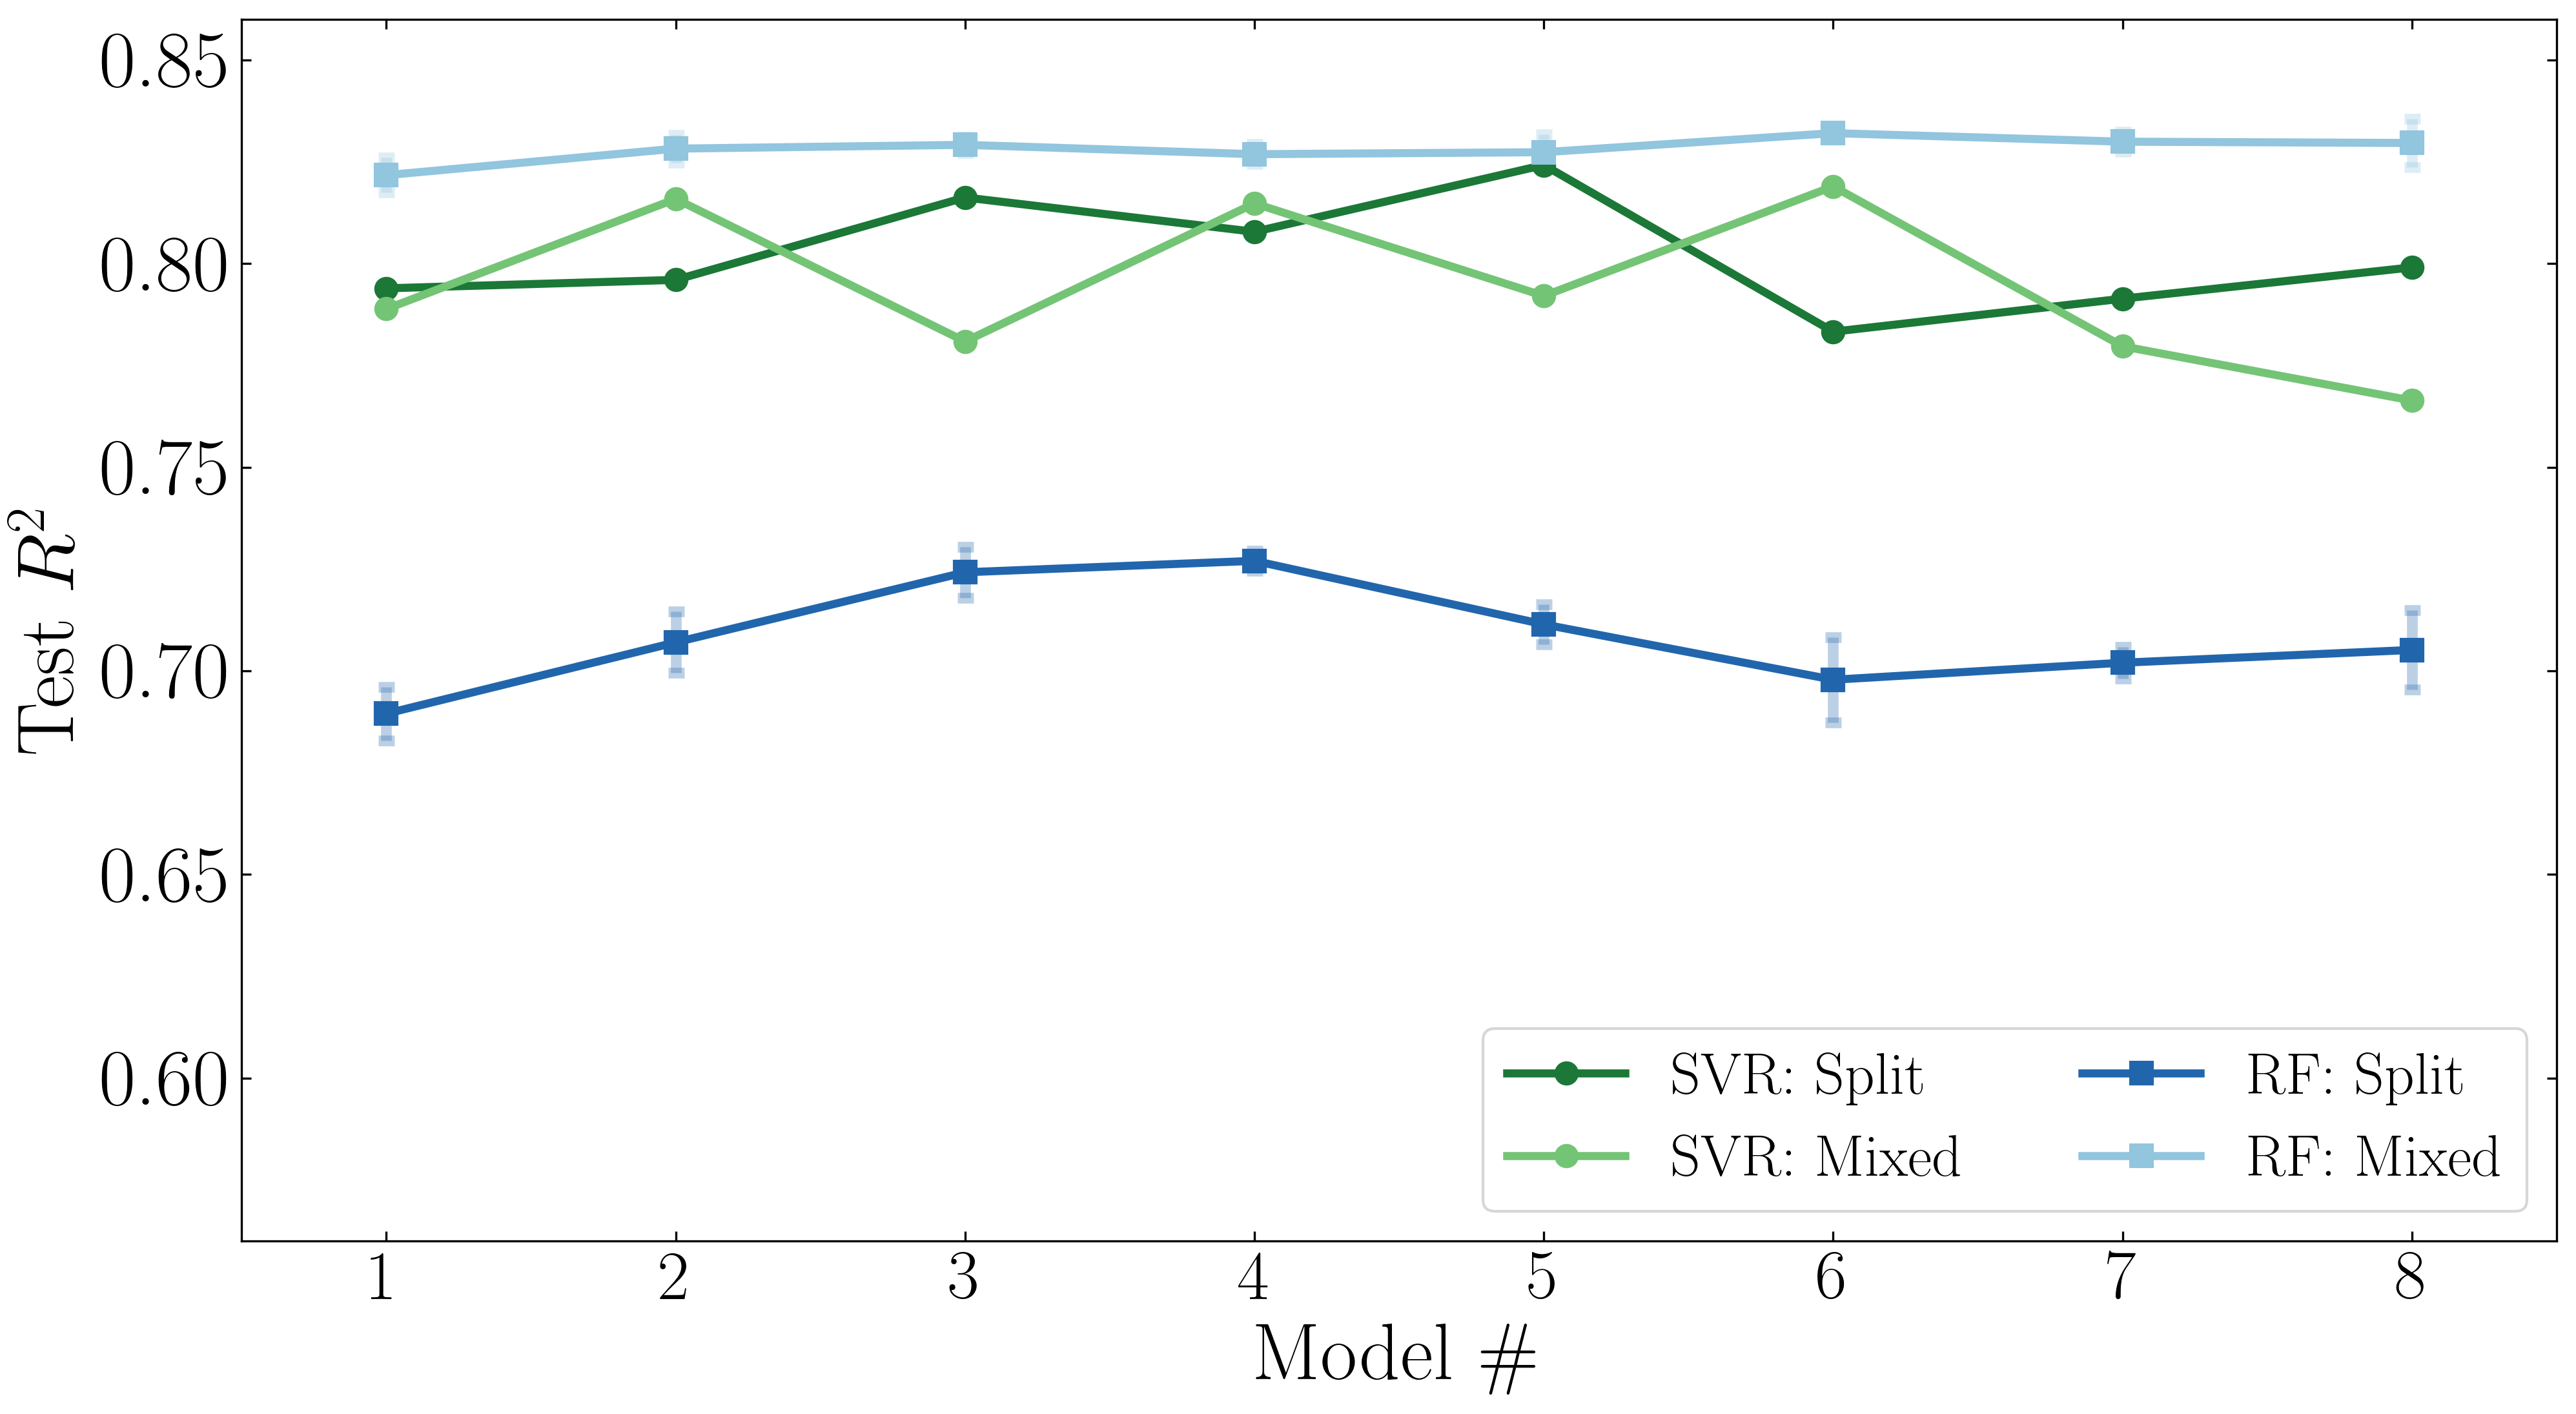


Saved: outputs/paper_plots/mixed_vs_domain_shift_comparison.pdf


In [23]:
# Figure R1: SVR vs RF — domain shift vs mixed split (computed live, no hardcoded values)
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "Computer Modern",
    "figure.dpi": 300,
    "font.size": 30,
})

# Feature sets — same ordering as model_comparison.py / Figure 3
# 1=Stel.pop., 2=+errors, 3=+kin., 4=+α, 5=+α+kin., 6=+struct., 7=+struct.+kin., 8=Complete
FEATURE_SETS = [
    ['met', 'tau'],
    ['met', 'tau', 'met_err', 'lin_age_err'],
    ['met', 'tau', 'met_err', 'lin_age_err', 'vdisp'],
    ['met', 'tau', 'met_err', 'lin_age_err', 'MgFe'],
    ['met', 'tau', 'met_err', 'lin_age_err', 'MgFe', 'vdisp'],
    ['met', 'tau', 'met_err', 'lin_age_err', 'logM', 'rad_kpc'],
    ['met', 'tau', 'met_err', 'lin_age_err', 'logM', 'rad_kpc', 'vdisp'],
    ['met', 'tau', 'met_err', 'lin_age_err', 'logM', 'rad_kpc', 'MgFe', 'vdisp'],
]

SVR_PARAMS = {'C': 5.0, 'epsilon': 0.03, 'kernel': 'poly', 'gamma': 0.01, 'degree': 3, 'coef0': 0.5}
RF_PARAMS  = {'max_depth': 8, 'max_features': 0.8, 'max_samples': 0.7,
              'min_samples_leaf': 3, 'min_samples_split': 5, 'n_estimators': 50}
RF_SEEDS = [3, 4, 5, 6, 7]

# Colors match Fig. 3 algorithm color families:
#   SVR=green in Fig. 3  → dark green (domain shift) / light green (mixed)
#   RF=blue in Fig. 3    → dark blue  (domain shift) / light blue  (mixed)
SVR_DS_COLOR  = '#1b7837'  # dark green
SVR_MIX_COLOR = '#74c476'  # light green
RF_DS_COLOR   = '#2166ac'  # dark blue
RF_MIX_COLOR  = '#92c5de'  # light blue

splits = {
    'domain_shift': (domain_train_df, domain_test_df),
    'mixed':        (mixed_train_df,  mixed_test_df),
}

def eval_r2(model_cls, params, tr, te, feats):
    sc = StandardScaler()
    X_tr = sc.fit_transform(tr[feats].values)
    X_te = sc.transform(te[feats].values)
    m = model_cls(**params)
    m.fit(X_tr, tr['DoR'].values)
    return r2_score(te['DoR'].values, m.predict(X_te))

print("Computing R² across 8 feature sets × 2 splits × 2 algorithms ...")
results = {}
for split_name, (tr, te) in splits.items():
    svr_r2 = [eval_r2(SVR, SVR_PARAMS, tr, te, feats) for feats in FEATURE_SETS]
    rf_per_seed = np.array([
        [eval_r2(RandomForestRegressor, {**RF_PARAMS, 'random_state': s}, tr, te, feats)
         for feats in FEATURE_SETS]
        for s in RF_SEEDS
    ])
    results[split_name] = {
        'SVR':    np.array(svr_r2),
        'RF':     rf_per_seed.mean(axis=0),
        'RF_std': rf_per_seed.std(axis=0),
    }
print("Done.\n")

# Summary table
print(f"{'#':<3} {'SVR-DS':>7} {'SVR-Mix':>8} {'RF-DS':>7} {'RF-Mix':>8}")
print("-" * 38)
for i in range(8):
    print(f"{i+1:<3} "
          f"{results['domain_shift']['SVR'][i]:>7.3f} "
          f"{results['mixed']['SVR'][i]:>8.3f} "
          f"{results['domain_shift']['RF'][i]:>7.3f} "
          f"{results['mixed']['RF'][i]:>8.3f}")

x = np.arange(1, 9)
fig, ax = plt.subplots(figsize=(14, 8))

# RF error bars
ax.errorbar(x, results['domain_shift']['RF'], yerr=results['domain_shift']['RF_std'],
            fmt='none', ecolor=RF_DS_COLOR,  alpha=0.3, capsize=3, elinewidth=4, capthick=4)
ax.errorbar(x, results['mixed']['RF'],        yerr=results['mixed']['RF_std'],
            fmt='none', ecolor=RF_MIX_COLOR, alpha=0.3, capsize=3, elinewidth=4, capthick=4)

ax.plot(x, results['domain_shift']['SVR'], 'o-', color=SVR_DS_COLOR,  lw=3, ms=8, label=r'SVR: Split')
ax.plot(x, results['mixed']['SVR'],        'o-', color=SVR_MIX_COLOR, lw=3, ms=8, label=r'SVR: Mixed')
ax.plot(x, results['domain_shift']['RF'],  's-', color=RF_DS_COLOR,   lw=3, ms=8, label=r'RF: Split')
ax.plot(x, results['mixed']['RF'],         's-', color=RF_MIX_COLOR,  lw=3, ms=8, label=r'RF: Mixed')

ax.set_xlabel(r'Model \#', fontsize=30)
ax.set_ylabel(r'Test $R^2$', fontsize=30)
ax.set_xlim(0.5, 8.5)
ax.set_xticks(x)
ax.set_xticklabels([str(i) for i in x], rotation=0, ha='center', fontsize=26)
ax.set_ylim(0.56, 0.86)
yticks = [0.6, 0.65, 0.7, 0.75, 0.8, 0.85]
ax.set_yticks(yticks)
ax.set_yticklabels([f'{y:.2f}' for y in yticks])
ax.tick_params(direction='in', top=True, right=True)
ax.legend(fontsize=22, loc='lower right', ncol=2)

fig.tight_layout()
out = 'outputs/paper_plots/mixed_vs_domain_shift_comparison.pdf'
fig.savefig(out, bbox_inches='tight')
plt.show()
print(f'\nSaved: {out}')